<a href="https://colab.research.google.com/github/gopalgupta46300-ui/AI_chatbot/blob/main/Cat_vs_Dog_classification_%7BDL%7D_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.


In [2]:
import os

# List the contents of the dataset directory
dataset_contents = os.listdir(path)
print("Contents of the dataset directory:")
for item in dataset_contents:
    print(item)

# Based on the name 'dog-and-cat-classification-dataset', it's likely an image dataset.
# If you were expecting a tabular dataset, please specify the filename (e.g., 'data.csv').
# If this is an image dataset, displaying 'rows' directly like a pandas DataFrame won't be appropriate.
# Instead, we might load and display some images.

Contents of the dataset directory:
PetImages


### Dataset Overview: Number of Images

Let's count the total number of images in the `PetImages` directory, which is likely structured into subdirectories for 'Dog' and 'Cat'. This will give us the 'length' of our image dataset.

In [3]:
import os

# Construct the full path to the PetImages directory
pet_images_path = os.path.join(path, 'PetImages')

# Initialize counts
total_images = 0
cat_images = 0
dog_images = 0

# Iterate through the subdirectories (e.g., 'Cat', 'Dog')
for category in os.listdir(pet_images_path):
    category_path = os.path.join(pet_images_path, category)
    if os.path.isdir(category_path):
        for filename in os.listdir(category_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                total_images += 1
                if category.lower() == 'cat':
                    cat_images += 1
                elif category.lower() == 'dog':
                    dog_images += 1

print(f"Total images in the dataset: {total_images}")
print(f"Number of Cat images: {cat_images}")
print(f"Number of Dog images: {dog_images}")


Total images in the dataset: 24998
Number of Cat images: 12499
Number of Dog images: 12499


### Displaying Sample Images

Now, let's visualize a few images from both the 'Cat' and 'Dog' categories to get a better understanding of the dataset.

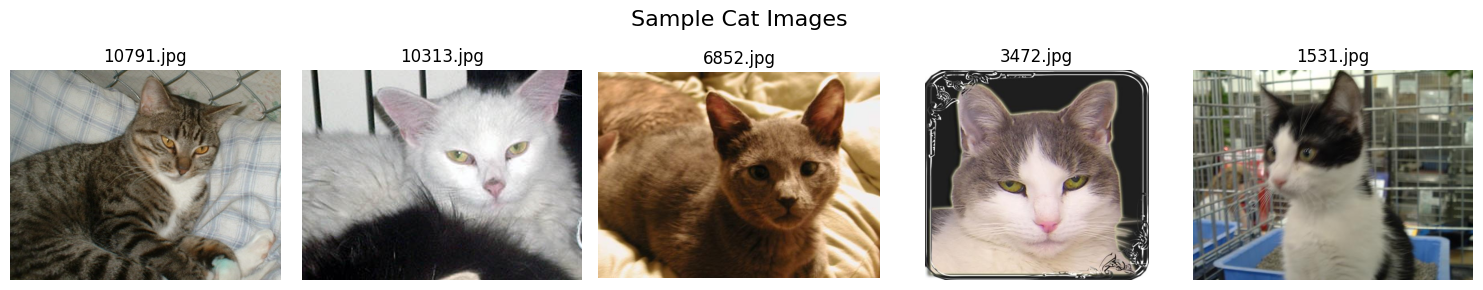

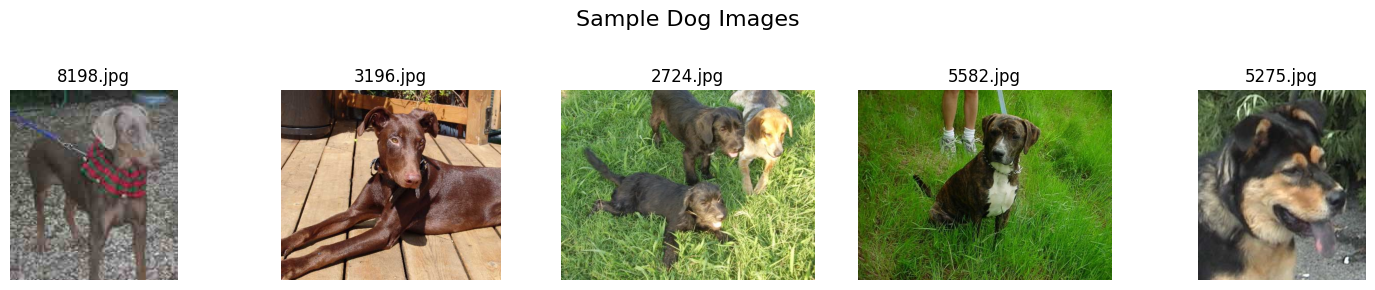

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Define paths for categories
cat_path = os.path.join(pet_images_path, 'Cat')
dog_path = os.path.join(pet_images_path, 'Dog')

# Get a list of image filenames for each category
cat_filenames = [os.path.join(cat_path, f) for f in os.listdir(cat_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
dog_filenames = [os.path.join(dog_path, f) for f in os.listdir(dog_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Function to display a random sample of images
def display_random_images(image_list, title, num_images=5):
    plt.figure(figsize=(15, 3))
    plt.suptitle(title, fontsize=16)
    selected_images = random.sample(image_list, min(num_images, len(image_list)))
    for i, img_path in enumerate(selected_images):
        try:
            img = mpimg.imread(img_path)
            plt.subplot(1, num_images, i + 1)
            plt.imshow(img)
            plt.title(os.path.basename(img_path))
            plt.axis('off')
        except Exception as e:
            print(f"Could not load image {img_path}: {e}")
            continue
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

# Display sample Cat images
display_random_images(cat_filenames, 'Sample Cat Images')

# Display sample Dog images
display_random_images(dog_filenames, 'Sample Dog Images')


In [5]:
from sklearn.model_selection import train_test_split
import numpy as np

# Combine cat and dog filenames and create labels
# Assuming 0 for cat and 1 for dog
all_filenames = cat_filenames + dog_filenames
all_labels = [0] * len(cat_filenames) + [1] * len(dog_filenames)

# Convert to numpy arrays for easier manipulation
all_filenames = np.array(all_filenames)
all_labels = np.array(all_labels)

# First split: 80% for training, 20% for temp (validation + test)
# We use stratify=all_labels to maintain the proportion of cats and dogs in each split
X_train, X_temp, y_train, y_temp = train_test_split(
    all_filenames, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

# Second split: 50% of temp for validation, 50% for test (which means 10% of total for each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Total images: {len(all_filenames)}")
print(f"Training images: {len(X_train)} ({len(X_train)/len(all_filenames):.1%})")
print(f"Validation images: {len(X_val)} ({len(X_val)/len(all_filenames):.1%})")
print(f"Test images: {len(X_test)} ({len(X_test)/len(all_filenames):.1%})")

# Store the split datasets for future use
# train_images = X_train
# train_labels = y_train
# val_images = X_val
# val_labels = y_val
# test_images = X_test
# test_labels = y_test

Total images: 24998
Training images: 19998 (80.0%)
Validation images: 2500 (10.0%)
Test images: 2500 (10.0%)


### Image Resizing and Preprocessing

Now that the dataset is split, we need to preprocess the images. This involves loading each image, resizing it to a uniform dimension (e.g., 256x256 pixels), and converting it into a NumPy array. This step is crucial for preparing the data for a deep learning model.

In [ ]:
from PIL import Image
import numpy as np
from tqdm import tqdm

IMAGE_SIZE = (256, 256)

def preprocess_image(image_path, size=IMAGE_SIZE):
    try:
        img = Image.open(image_path).convert('RGB') # Ensure image is RGB
        img = img.resize(size)
        return np.array(img)
    except Exception as e:
        # Handle corrupted images or other loading errors by returning None
        print(f"Error processing image {image_path}: {e}")
        return None

# Process training images
print(f"Processing {len(X_train)} training images...")
processed_train_images = []
processed_train_labels = []
for i, img_path in enumerate(tqdm(X_train)):
    processed_img = preprocess_image(img_path)
    if processed_img is not None:
        processed_train_images.append(processed_img)
        processed_train_labels.append(y_train[i])

X_train_processed = np.array(processed_train_images)
y_train_processed = np.array(processed_train_labels)

# Process validation images
print(f"Processing {len(X_val)} validation images...")
processed_val_images = []
processed_val_labels = []
for i, img_path in enumerate(tqdm(X_val)):
    processed_img = preprocess_image(img_path)
    if processed_img is not None:
        processed_val_images.append(processed_img)
        processed_val_labels.append(y_val[i])

X_val_processed = np.array(processed_val_images)
y_val_processed = np.array(processed_val_labels)

# Process test images
print(f"Processing {len(X_test)} test images...")
processed_test_images = []
processed_test_labels = []
for i, img_path in enumerate(tqdm(X_test)):
    processed_img = preprocess_image(img_path)
    if processed_img is not None:
        processed_test_images.append(processed_img)
        processed_test_labels.append(y_test[i])

X_test_processed = np.array(processed_test_images)
y_test_processed = np.array(processed_test_labels)

print("\nImage preprocessing complete!")
print(f"Resized training images shape: {X_train_processed.shape}")
print(f"Resized validation images shape: {X_val_processed.shape}")
print(f"Resized test images shape: {X_test_processed.shape}")

Processing 19998 training images...


100%|██████████| 19998/19998 [04:43<00:00, 70.53it/s]


Processing 2500 validation images...


 15%|█▌        | 377/2500 [00:06<00:31, 67.78it/s]/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
 68%|██████▊   | 1691/2500 [00:25<00:11, 71.58it/s]

### Data Normalization

Before feeding the image data into a neural network, it's a common practice to normalize the pixel values. This typically involves scaling the pixel intensities from the original range (0-255) to a new range (0-1). Normalization helps in faster convergence during training and can improve model performance.

In [ ]:
# Normalize pixel values to be between 0 and 1
X_train_processed = X_train_processed.astype('float32') / 255.0
X_val_processed = X_val_processed.astype('float32') / 255.0
X_test_processed = X_test_processed.astype('float32') / 255.0

print("Image data normalized.")

### Build and Train a Keras Model

Now, let's define a simple Convolutional Neural Network (CNN) using TensorFlow's Keras API. This model will take the resized and normalized images as input and classify them as either 'cat' or 'dog'. We will then compile and train this model using our prepared training and validation datasets.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the Keras model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display model summary
model.summary()

### Train the Model

We will now train the defined CNN model using the training data and validate its performance on the validation set. We'll use a batch size of 32 as requested.

In [ ]:
BATCH_SIZE = 32
EPOCHS = 10 # You can adjust the number of epochs

history = model.fit(X_train_processed, y_train_processed,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_val_processed, y_val_processed))

### Evaluate the Model

After training, it's important to evaluate the model's performance on the unseen test dataset to get an unbiased estimate of its generalization capability.

In [ ]:
test_loss, test_acc = model.evaluate(X_test_processed, y_test_processed, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")

NameError: name 'X_test_processed' is not defined

### Data Normalization

Before feeding the image data into a neural network, it's a common practice to normalize the pixel values. This typically involves scaling the pixel intensities from the original range (0-255) to a new range (0-1). Normalization helps in faster convergence during training and can improve model performance.

In [ ]:
# Normalize pixel values to be between 0 and 1
X_train_processed = X_train_processed.astype('float32') / 255.0
X_val_processed = X_val_processed.astype('float32') / 255.0
X_test_processed = X_test_processed.astype('float32') / 255.0

print("Image data normalized.")

NameError: name 'X_train_processed' is not defined

### Build and Train a Keras Model

Now, let's define a simple Convolutional Neural Network (CNN) using TensorFlow's Keras API. This model will take the resized and normalized images as input and classify them as either 'cat' or 'dog'. We will then compile and train this model using our prepared training and validation datasets.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the Keras model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,105 (56.61 MB)

 Trainable params: 14,839,105 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

We will now train the defined CNN model using the training data and validate its performance on the validation set. We'll use a batch size of 32 as requested.

In [ ]:
BATCH_SIZE = 32
EPOCHS = 10 # You can adjust the number of epochs

history = model.fit(X_train_processed, y_train_processed,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_val_processed, y_val_processed))

NameError: name 'X_train_processed' is not defined

### Evaluate the Model

After training, it's important to evaluate the model's performance on the unseen test dataset to get an unbiased estimate of its generalization capability.

In [ ]:
test_loss, test_acc = model.evaluate(X_test_processed, y_test_processed, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")

NameError: name 'X_test_processed' is not defined